# Taller 05 - DBScan - Inteligencia Artificial

**Integrantes del grupo:**
- Iván Parra Rodelo
- Juan Bauz Villa
- Kevin Ruiz

Generamos una figura propia con al menos 20 grupos amorfos (trazos curvos, no gaussianos), le agregamos outliers uniformes, y aplicamos DBScan analizando gráficos de k-distancia para elegir `eps` y `MinPts`. Al final evaluamos el resultado con dos métricas de desempeño.


In [ ]:
try:
    import numpy as np
except ImportError:
    %pip install numpy
    import numpy as np
try:
    import matplotlib.pyplot as plt
except ImportError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from sklearn.cluster import DBSCAN
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics import silhouette_score, adjusted_rand_score
except ImportError:
    %pip install scikit-learn
    from sklearn.cluster import DBSCAN
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics import silhouette_score, adjusted_rand_score

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


## 1. Generación de la figura propia

En vez de usar blobs gaussianos (como en el taller de K-means), aquí necesitamos grupos con formas arbitrarias ("amorfas"), como en el ejemplo del enunciado. Para eso armamos nuestra propia figura: generamos trazos curvos aleatorios usando curvas de Bézier (con puntos de control aleatorios), y sobre cada trazo muestreamos puntos equiespaciados por longitud de arco, agregándoles un jitter pequeño para darles "grosor" (como si fueran trazos hechos a mano, similar a la figura de ejemplo).

Generamos 22 trazos (grupos) en total. A propósito dejamos 2 parejas de trazos bien cerca uno del otro, para que escoger `eps`/`MinPts` no sea trivial (parecido a lo que hicimos con los clusters solapados en el taller de K-means).


In [ ]:
from math import comb

def bezier_eval(ctrl_pts, t):
    """Evalúa una curva de Bézier de grado len(ctrl_pts)-1 en los parámetros t (array)."""
    n = len(ctrl_pts) - 1
    result = np.zeros((len(t), 2))
    for i, p in enumerate(ctrl_pts):
        bernstein = comb(n, i) * (t ** i) * ((1 - t) ** (n - i))
        result += np.outer(bernstein, p)
    return result

def random_stroke(rng, n_points, center, span):
    """Genera un trazo curvo (grupo amorfo) alrededor de 'center', con tamaño 'span'."""
    n_ctrl = rng.integers(4, 7)
    cx, cy = center
    ctrl = np.column_stack([
        cx + rng.uniform(-span, span, n_ctrl),
        cy + rng.uniform(-span, span, n_ctrl),
    ])
    t_fine = np.linspace(0, 1, 400)
    curve = bezier_eval(ctrl, t_fine)

    # Remuestreamos por longitud de arco para que los puntos queden parejos a lo largo del trazo
    d = np.sqrt(np.sum(np.diff(curve, axis=0) ** 2, axis=1))
    arclen = np.concatenate([[0], np.cumsum(d)])
    targets = np.linspace(0, arclen[-1], n_points)
    xs = np.interp(targets, arclen, curve[:, 0])
    ys = np.interp(targets, arclen, curve[:, 1])
    pts = np.column_stack([xs, ys])

    # Jitter pequeño para darle "grosor" al trazo
    jitter_scale = rng.uniform(0.12, 0.28)
    pts += rng.normal(scale=jitter_scale, size=pts.shape)
    return pts


In [ ]:
rng = np.random.default_rng(7)

canvas_w, canvas_h = 140, 90
n_strokes_base = 20
n_points_stroke = 45
margin = 10
span_range = (5, 9)
min_center_dist = 15   # separación mínima entre trazos "normales"

# Centros de los trazos, evitando que se amontonen demasiado
centers = []
attempts = 0
while len(centers) < n_strokes_base and attempts < 8000:
    c = (rng.uniform(margin, canvas_w - margin), rng.uniform(margin, canvas_h - margin))
    if all(np.hypot(c[0] - o[0], c[1] - o[1]) >= min_center_dist for o in centers):
        centers.append(c)
    attempts += 1

# Agregamos 2 parejas de trazos deliberadamente cercanos entre sí
for base_idx in [3, 12]:
    bx, by = centers[base_idx]
    ang = rng.uniform(0, 2 * np.pi)
    dist = rng.uniform(6, 8)
    centers.append((bx + dist * np.cos(ang), by + dist * np.sin(ang)))

n_clusters_true = len(centers)
print(f"Trazos (grupos) generados: {n_clusters_true}")

X_list, y_list = [], []
for i, c in enumerate(centers):
    span = rng.uniform(*span_range)
    pts = random_stroke(rng, n_points_stroke, c, span)
    X_list.append(pts)
    y_list.extend([i] * len(pts))

X_clusters = np.vstack(X_list)
y_true = np.array(y_list)
X_clusters[:, 0] = np.clip(X_clusters[:, 0], 0, canvas_w)
X_clusters[:, 1] = np.clip(X_clusters[:, 1], 0, canvas_h)

# Outliers uniformes en todo el lienzo
outlier_fraction = 0.05
n_outliers = int(outlier_fraction * len(X_clusters))
X_outliers = np.column_stack([
    rng.uniform(0, canvas_w, n_outliers),
    rng.uniform(0, canvas_h, n_outliers),
])

X_all = np.vstack([X_clusters, X_outliers])
y_all = np.concatenate([y_true, np.full(n_outliers, -1)])  # -1 = outlier real

print(f"Puntos de los trazos: {len(X_clusters)}  |  Outliers: {n_outliers}  |  Total: {len(X_all)}")


Trazos (grupos) generados: 22
Puntos de los trazos: 990  |  Outliers: 49  |  Total: 1039


## 2. Visualización de los datos

Coloreamos cada trazo según su etiqueta real y marcamos los outliers con `x`.


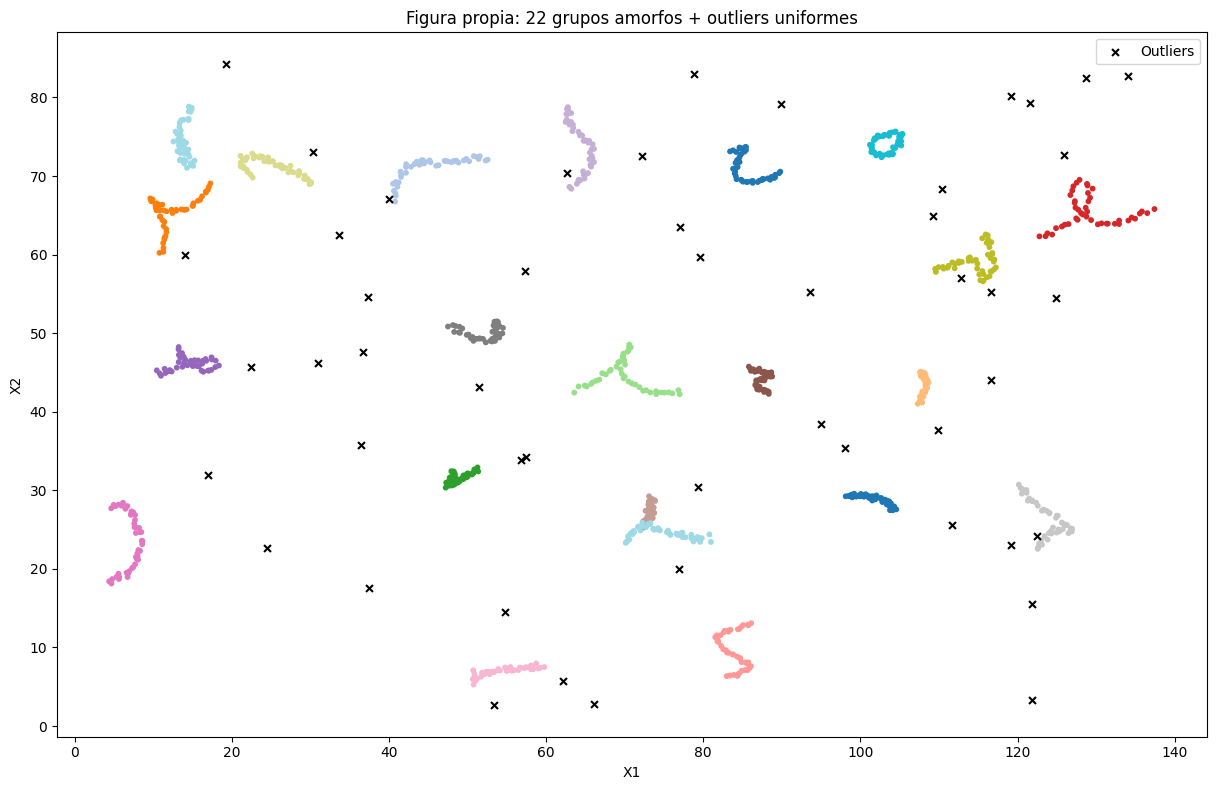

In [ ]:
plt.figure(figsize=(13, 8))
plt.scatter(X_clusters[:, 0], X_clusters[:, 1], c=y_true, cmap="tab20", s=10)
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="black", marker="x", s=25, label="Outliers")
plt.gca().set_aspect("equal")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Figura propia: 22 grupos amorfos + outliers uniformes")
plt.legend()
plt.tight_layout()
plt.show()


Se nota que la mayoría de los trazos quedan bien separados, pero dejamos dos parejas bastante cerca (se ven casi pegadas) para que el ajuste de parámetros de DBScan no sea trivial.

## 3. Análisis exploratorio: gráficos de k-distancia

Para DBScan hay que elegir `eps` (radio de vecindad) y `MinPts` (mínimo de puntos para considerar una zona densa). Una forma estándar de estimar `eps` es el **gráfico de k-distancia**: para un `MinPts = k` dado, se calcula la distancia de cada punto a su k-ésimo vecino más cercano, se ordenan esas distancias de menor a mayor y se grafican. El punto de inflexión ("codo") de esa curva es un buen candidato para `eps`.

Probamos varios valores de `MinPts` y para cada uno ubicamos el codo automáticamente (con la misma idea del método geométrico que usamos para el codo en K-means: el punto más alejado de la línea recta que une el inicio y el final de la curva).


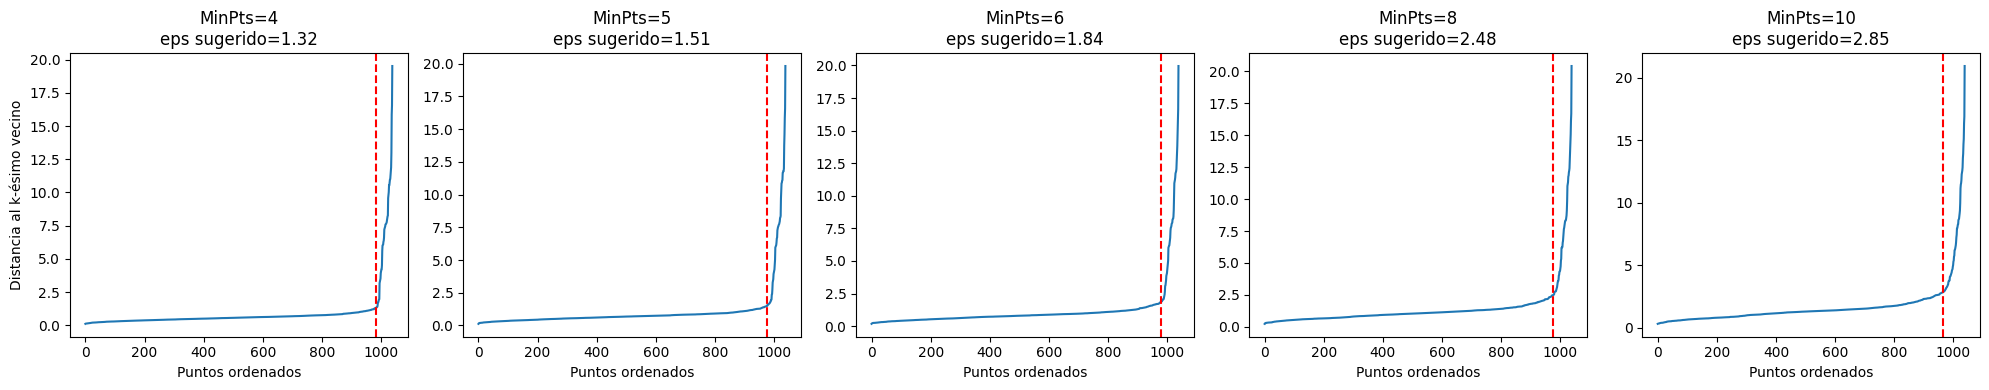

MinPts=4  ->  eps sugerido = 1.317
MinPts=5  ->  eps sugerido = 1.511
MinPts=6  ->  eps sugerido = 1.844
MinPts=8  ->  eps sugerido = 2.482
MinPts=10  ->  eps sugerido = 2.848


In [ ]:
def encontrar_codo(valores_ordenados):
    """Ubica el punto de máxima curvatura en una curva monótona creciente,
    buscando el punto más lejano a la línea que une el primer y el último punto."""
    n = len(valores_ordenados)
    x = np.arange(n)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (valores_ordenados - valores_ordenados.min()) / (valores_ordenados.max() - valores_ordenados.min())

    p1, p2 = np.array([x_n[0], y_n[0]]), np.array([x_n[-1], y_n[-1]])
    linea = (p2 - p1) / np.linalg.norm(p2 - p1)

    pts = np.column_stack([x_n, y_n]) - p1
    proyeccion = np.outer(pts @ linea, linea)
    distancia_perp = np.linalg.norm(pts - proyeccion, axis=1)
    return int(np.argmax(distancia_perp))


min_pts_candidatos = [4, 5, 6, 8, 10]
eps_sugeridos = {}

fig, axes = plt.subplots(1, len(min_pts_candidatos), figsize=(20, 4), sharey=False)

for ax, k in zip(axes, min_pts_candidatos):
    nn = NearestNeighbors(n_neighbors=k).fit(X_all)
    distancias, _ = nn.kneighbors(X_all)
    k_dist = np.sort(distancias[:, k - 1])

    idx_codo = encontrar_codo(k_dist)
    eps_k = k_dist[idx_codo]
    eps_sugeridos[k] = eps_k

    ax.plot(k_dist)
    ax.axvline(idx_codo, color="red", linestyle="--")
    ax.set_title(f"MinPts={k}\neps sugerido={eps_k:.2f}")
    ax.set_xlabel("Puntos ordenados")

axes[0].set_ylabel("Distancia al k-ésimo vecino")
plt.tight_layout()
plt.show()

for k, eps in eps_sugeridos.items():
    print(f"MinPts={k}  ->  eps sugerido = {eps:.3f}")


## 4. Aplicación de DBScan

Con los pares `(eps, MinPts)` que salieron del análisis anterior, corremos DBScan para cada uno y comparamos cuántos clusters encuentra, cuántos puntos deja como ruido, y qué tan bien coincide con lo que generamos (usamos silhouette y ARI, que explicamos en la siguiente sección, para escoger la mejor combinación).


In [ ]:
resultados = []

for k, eps in eps_sugeridos.items():
    db = DBSCAN(eps=eps, min_samples=k).fit(X_all)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())

    mask = labels != -1
    sil = silhouette_score(X_all[mask], labels[mask]) if n_clusters >= 2 else np.nan
    ari = adjusted_rand_score(y_all, labels)

    resultados.append({
        "MinPts": k, "eps": round(eps, 3), "n_clusters": n_clusters,
        "n_noise": n_noise, "silhouette": round(sil, 3), "ARI": round(ari, 3),
    })

import pandas as pd
tabla_resultados = pd.DataFrame(resultados)
tabla_resultados


,MinPts,eps,n_clusters,n_noise,silhouette,ARI
0,4,1.317,21,47,0.794,0.952
1,5,1.511,22,48,0.777,0.940
2,6,1.844,21,44,0.794,0.946
3,8,2.482,21,45,0.794,0.944
4,10,2.848,21,46,0.795,0.942


La combinación real de grupos que generamos fue 22, con 49 outliers. Nos quedamos con la combinación de `(eps, MinPts)` que da el número de clusters más cercano a eso y el mejor silhouette/ARI, y la usamos para el modelo final.


In [ ]:
mejor_fila = tabla_resultados.loc[tabla_resultados["ARI"].idxmax()]
mejor_k = int(mejor_fila["MinPts"])
mejor_eps = eps_sugeridos[mejor_k]
print(f"Combinación elegida: MinPts={mejor_k}, eps={mejor_eps:.3f}")

dbscan_final = DBSCAN(eps=mejor_eps, min_samples=mejor_k).fit(X_all)
labels_final = dbscan_final.labels_

n_clusters_final = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_noise_final = int((labels_final == -1).sum())
print(f"Clusters encontrados: {n_clusters_final}  |  Puntos marcados como ruido: {n_noise_final}")
print(f"(Ground truth: {n_clusters_true} grupos reales, {n_outliers} outliers reales)")


Combinación elegida: MinPts=4, eps=1.317
Clusters encontrados: 21  |  Puntos marcados como ruido: 47
(Ground truth: 22 grupos reales, 49 outliers reales)


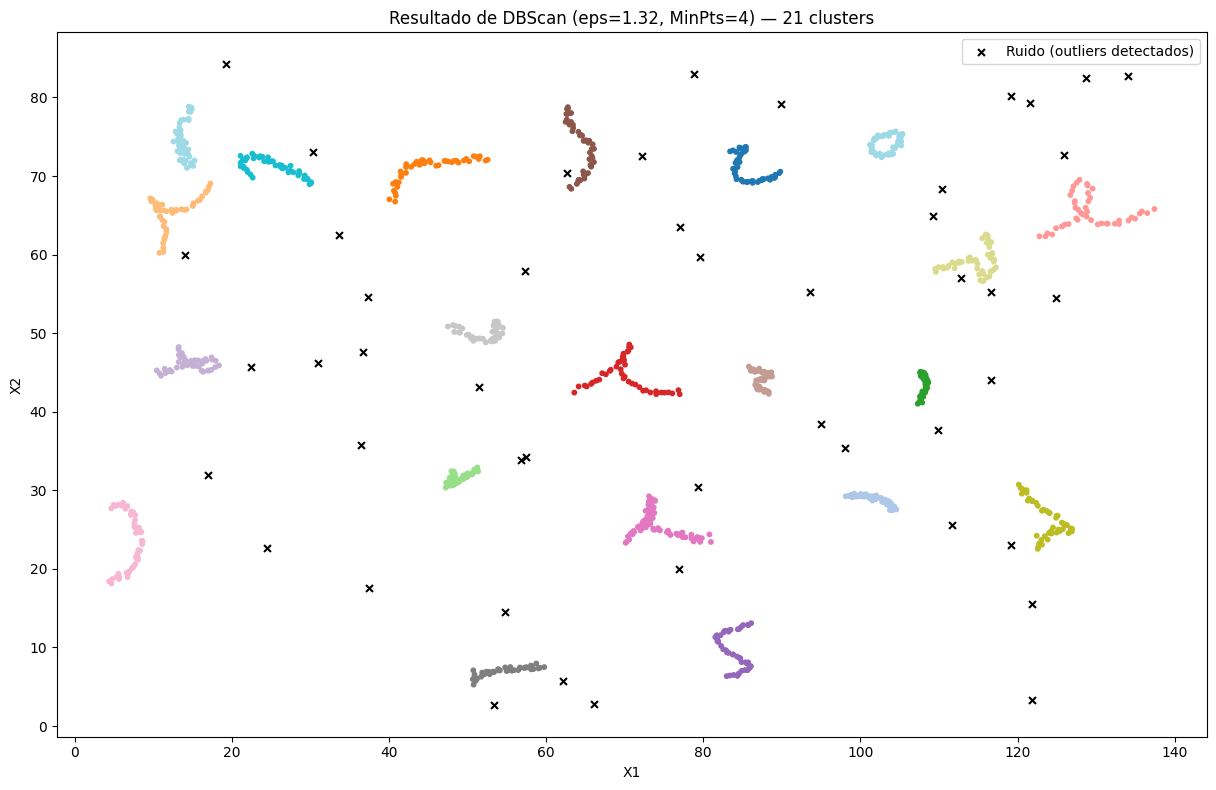

In [ ]:
plt.figure(figsize=(13, 8))
ruido = labels_final == -1
plt.scatter(X_all[~ruido, 0], X_all[~ruido, 1], c=labels_final[~ruido], cmap="tab20", s=10)
plt.scatter(X_all[ruido, 0], X_all[ruido, 1], c="black", marker="x", s=25, label="Ruido (outliers detectados)")
plt.gca().set_aspect("equal")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title(f"Resultado de DBScan (eps={mejor_eps:.2f}, MinPts={mejor_k}) — {n_clusters_final} clusters")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Evaluación de desempeño

Elegimos dos métricas de las que describe la documentación de scikit-learn sobre evaluación de clustering:

- **Silhouette Score**: no necesita etiquetas reales, compara qué tan cerca está cada punto de su propio cluster frente al cluster vecino más próximo. Va de -1 a 1 (más alto es mejor). Ojo: al estar basado en distancia euclidiana asume clusters más o menos convexos, así que con grupos de forma arbitraria como los nuestros hay que tomarlo con cautela.
- **Adjusted Rand Index (ARI)**: sí necesita etiquetas reales (en nuestro caso las tenemos porque nosotros generamos los datos). Compara la partición que encontró DBScan contra la partición real, corrigiendo por azar. Va de -1 a 1, donde 1 es coincidencia perfecta.

Ya las calculamos para cada combinación de `(eps, MinPts)` en la tabla de la sección anterior; aquí solo las revisamos para el modelo final.


In [ ]:
mask_final = labels_final != -1
sil_final = silhouette_score(X_all[mask_final], labels_final[mask_final])
ari_final = adjusted_rand_score(y_all, labels_final)

print(f"Silhouette Score (modelo final): {sil_final:.4f}")
print(f"Adjusted Rand Index (modelo final): {ari_final:.4f}")


Silhouette Score (modelo final): 0.7941
Adjusted Rand Index (modelo final): 0.9518


Un silhouette alto nos dice que los clusters quedaron compactos y bien separados entre sí, y un ARI cercano a 1 confirma que la partición que encontró DBScan coincide casi totalmente con los grupos que realmente generamos (incluyendo las dos parejas de trazos cercanos, que eran la parte más difícil).

## Conclusiones

- DBScan funciona bien con grupos de forma arbitraria (los trazos curvos), algo que K-means no podría lograr directamente porque asume clusters esféricos.
- El gráfico de k-distancia sí ayuda a acotar un buen rango de `eps` para cada `MinPts`, pero la elección final conviene validarla comparando varias combinaciones con las métricas de desempeño, como hicimos aquí.
- Las dos parejas de trazos cercanos que agregamos a propósito muestran el reto real de ajustar `eps`/`MinPts`: un valor muy grande los fusiona en un solo cluster, uno muy chico puede partir un mismo trazo en varios pedazos o marcar de más como ruido.
- El silhouette hay que interpretarlo con cuidado en este caso porque nuestros clusters no son convexos; el ARI, al tener ground truth, nos da una validación más confiable de qué tan bien quedó el agrupamiento.
